# 06 · Exit-policy study, liquidation map

**Question (BACKLOG research item 2, candidate B of the exhaustion brainstorm).** Does a liquidation map estimated from
public open interest and taker flow carry information an exit could use — a **magnet** (price drawn to dense clusters),
a **turn** (price reverses once a cluster is consumed), or an **end of forced flow** (a burst of estimated liquidations
in the trade's favour is a time to leave)?

Frozen rules: [PREREGISTRATION_LIQMAP.md](PREREGISTRATION_LIQMAP.md) v1.1, F0 2026-09-18 10:02 UTC. Write-up:
[findings_liqmap.md](findings_liqmap.md).

**Verdict: `REPLICATED: up_touch, down_touch`. What it is worth: nothing for any strategy, and — once §4 below is
applied — nothing about the map's placement either. Do not quote §3 without §4.**

This notebook is a check on the frozen run, not a second run. It reloads `results/liqmap/q1_states*.csv.gz` and
`q2_events*.csv.gz` and re-derives each headline number with the study's own statistics, then asserts it equals the
saved result. No map is built here.

In [1]:
import json, sys
from datetime import datetime, timezone
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PREREGISTRATION_LIQMAP.md").exists(), "execute from studies/notebooks/exit_policy_2026_09"
sys.path.insert(0, str(STUDY)); sys.path.insert(0, str(STUDY.parent / "orb_study"))
import liqmap_lib as L, micro_lib as M
from review_plots import AXIS, INK2, NEUTRAL, SERIES, style
pd.set_option("display.width", 230); pd.set_option("display.max_columns", 40)

R = STUDY / "results" / "liqmap"
F0, PRE, REP, VER, HOLD, SEC = (json.loads((R / f).read_text()) for f in (
    "freeze_F0.json", "preconditions.json", "report.json", "verdict.json", "holdout_eth.json",
    "secondary_section7.json"))

changed = [f for f, h in F0["files"].items() if M.sha256(M.ROOT / f) != h]
assert not changed, f"changed since F0: {changed}"
assert M.sha256(R / "q1_states.csv.gz") == REP["q1_states_sha256"]
assert M.sha256(R / "q2_events.csv.gz") == REP["q2_events_sha256"]
assert M.sha256(R / "verdict.json") == SEC["verdict_sha256"], "section 7 was computed on a different verdict"

print("F0", F0["created_utc"], "| BTC outcomes", REP["created_utc"], "| ETH replication", HOLD["created_utc"])
print("every file in the F0 manifest still matches its hash; the saved tables match report.json and section 7")
print("family (fixed before any outcome):", F0["family"])
print("verdict:", VER["verdict"])
print("permits:", VER["permits"])
print("labels:", json.dumps({k: v for k, v in VER["classifications"].items() if not k.startswith("squeeze_bull")},
                            indent=1))

F0 2026-09-18T10:02:21+00:00 | BTC outcomes 2026-09-18T10:03:49+00:00 | ETH replication 2026-09-18T10:05:54+00:00
every file in the F0 manifest still matches its hash; the saved tables match report.json and section 7
family (fixed before any outcome): ['up_touch', 'up_turn', 'down_touch', 'down_turn', 'chento:EV2']
verdict: REPLICATED: up_touch, down_touch
permits: nothing in production; a replicated test permits only a separate stage-B pre-registration
labels: {
 "up_touch": "INFORMATIVE",
 "up_turn": "UNDETERMINED",
 "down_touch": "INFORMATIVE",
 "down_turn": "UNDETERMINED",
 "chento:EV1": "DESCRIPTIVE",
 "chento:EV1_ctrl": "DESCRIPTIVE",
 "chento:EV2": "UNDETERMINED",
 "chento:EV2_ctrl": "DESCRIPTIVE",
 "chento:EV2_against": "DESCRIPTIVE"
}


## 1. What was asked, and what the control map is

The map is estimated on the archive's 5-minute grid: open-interest increases say how much was opened, the bin's taker
share says which side was the aggressor, fixed leverage tiers say how far away that position would be liquidated, price
traversal removes mass it has already run through, and a 30-day ring forgets the rest.

**The control is not a permuted level.** Every cluster the map produces sits in territory price has not visited since
the mass was added, at a distance that depends on recent volatility; a level drawn without that geometry measures the
geometry instead of the information. So the control is **a second map built by the identical code path on the identical
price path with the information set to a constant** — one unit of mass every bin, half long, half short, no
open-interest-decrease removal. Its clusters and bursts are what the model would say knowing only the price path, and
every test below is paired against it at the same state or the same trade.

The constants below are read from the frozen library, not retyped.

In [2]:
print("map (section 3)     ", f"tiers {L.TIERS} at weights {L.TIER_W} | mmr {L.MMR} |",
      f"bucket {(L.BUCKET - 1) * 1e4:.0f} bp | ring {L.RING_DAYS} d | warm-up {L.WARMUP_DAYS} d")
print("features (section 4)", f"search band ±{L.BAND:.0%} | density cut: top tercile of share over the trailing",
      f"{L.TERCILE_DAYS} d | burst = 3 bins summed ≥ the {L.BURST_PCT:.0f}th percentile of the trailing",
      f"{L.BURST_WINDOW:,} bins (lag {L.BURST_LAG})")
print("Q1 (section 5)      ", f"touch window {L.TOUCH_MIN:,} min | turn scan {L.TURN_MIN} min |",
      f"turn band ±{L.TURN_BAND:.0%} | equivalence: touch ±{L.BANDS['touch'][1] * 100:.0f} pp,",
      f"turn ±{L.BANDS['turn'][1] * 100:.0f} pp")
print("Q2 (section 5)      ", f"profit bin {L.BIN_R} R | era pool ±{L.ERA_DAYS} d | ≥ {L.MIN_CONTROLS} controls |",
      f"family needs {L.MIN_EVENT_TRADES} included trades | comparator floor {L.SIGN_CONTROL_MIN} |",
      f"equivalence ±{L.EQUIVALENCE_R} R")
print("claimed signs       ", L.CLAIMED_SIGN, "— Q1 claims the map's level beats the control's; Q2 claims holding "
      "after the event is worth less")

map (section 3)      tiers (10.0, 25.0, 50.0, 100.0) at weights (0.4, 0.3, 0.2, 0.1) | mmr 0.004 | bucket 10 bp | ring 30 d | warm-up 30 d
features (section 4) search band ±5% | density cut: top tercile of share over the trailing 30 d | burst = 3 bins summed ≥ the 99th percentile of the trailing 8,640 bins (lag 3)
Q1 (section 5)       touch window 1,440 min | turn scan 240 min | turn band ±1% | equivalence: touch ±2 pp, turn ±5 pp
Q2 (section 5)       profit bin 0.25 R | era pool ±365 d | ≥ 3 controls | family needs 30 included trades | comparator floor 10 | equivalence ±0.1 R
claimed signs        {'Q1': 1, 'Q2': -1} — Q1 claims the map's level beats the control's; Q2 claims holding after the event is worth less


## 2. The preconditions, all eight of which passed

L1 re-verified 3,954 archive zips against their checksums and every built array, panel, feature file and ledger against
its recorded hash. L2 pinned the populations to the earlier arms' trades. L3 is the fixture suite. L4 is causality: five
cuts on the real BTC series and five more on ETH, masking every price minute at or after the cut and every snapshot
stamped later than five minutes before it, with zero differences in any map, feature, threshold or event at or before
the cut.

In [3]:
print("preconditions:", {k: PRE[k]["pass"] for k in PRE if k.startswith("L")}, "| overall", PRE["pass"])
print("L1  archive zips verified:", PRE["L1"]["metrics_zips"]["verified"],
      "| failed:", PRE["L1"]["metrics_zips"]["failed"] or "none",
      "| missing days:", PRE["L1"]["metrics_zips"]["missing_in_archive"] or "none")
print("L2  chento", PRE["L2"]["chento"], "| squeeze_bull", PRE["L2"]["squeeze_bull"],
      "| secondary", PRE["L2"]["squeeze_bull_secondary"]["trades"])
print("    entries equal the perp close before the entry minute on both decision populations:",
      PRE["L2"]["entry_equals_previous_close"]["gated_on"],
      {p: v["above_1e-9"] for p, v in PRE["L2"]["entry_equals_previous_close"]["by_population"].items()},
      "rows above 1e-9")
print("L3 ", PRE["L3"]["summary"])
print("L4  BTC cuts", [c["cut_utc"][:10] for c in PRE["L4"]["cuts"]],
      "→ differences", [sum(c["differences"].values()) for c in PRE["L4"]["cuts"]])
print("    ETH cuts", [c["cut_utc"][:10] for c in HOLD["L4_eth"]["cuts"]],
      "→ differences", [sum(c["differences"].values()) for c in HOLD["L4_eth"]["cuts"]])

preconditions: {'L1': True, 'L2': True, 'L3': True, 'L4': True, 'L5': True, 'L6': True, 'L7': True, 'L8': True} | overall True
L1  archive zips verified: 3954 | failed: none | missing days: none
L2  chento {'trades': 392, 'equals_A0': True, 'BTC': 208, 'ETH': 184, 'ETH_from_2022_01_01': 176} | squeeze_bull {'trades': 122, 'equals_S0': True} | secondary 301
    entries equal the perp close before the entry minute on both decision populations: ['chento', 'squeeze_bull'] {'chento': 0, 'squeeze_bull': 0, 'squeeze_bull_secondary': 7} rows above 1e-9
L3  57 passed in 4.54s
L4  BTC cuts ['2021-05-12', '2023-05-28', '2023-06-09', '2024-09-19', '2025-06-05'] → differences [0, 0, 0, 0, 0]
    ETH cuts ['2022-06-30', '2024-02-02', '2024-02-12', '2025-02-11', '2025-09-02'] → differences [0, 0, 0, 0, 0]


### L5 — does the map track measured liquidations?

L5 fixed the family before any outcome existed, against Coinalyze's daily liquidation history for the Binance USDT
perpetual itself. Its day convention is not documented, so it was **pinned first**, before any correlation was taken, by
reading the two days that must dominate their neighbours on the long side: 2025-10-10 and 2024-08-05. Both say "day
start", and they agree, so the study continued.

In [4]:
dc = PRE["L5"]["day_convention"]
probes = []
for p in dc["probes"]:
    days = sorted(p["values"])
    probes.append({"probe": p["event"],
                   "day before": f"{days[0]}  ${p['values'][days[0]] / 1e6:,.1f} M",
                   "the day itself": f"{days[1]}  ${p['values'][days[1]] / 1e6:,.1f} M",
                   "day after": f"{days[2]}  ${p['values'][days[2]] / 1e6:,.1f} M",
                   "largest long side": p["argmax"], "reading": p["convention"]})
display(pd.DataFrame(probes).set_index("probe"))
print("the two probes agree:", dc["agree"], "→ convention", dc["convention"], "| days compared:", PRE["L5"]["days"])

rows = []
for side in ("long", "short"):
    s = PRE["L5"][side]
    rows.append({"side": side, "ρ raw, lag −1": s["rho_raw_by_lag"]["-1"], "ρ raw, lag 0": s["rho_raw_by_lag"]["0"],
                 "ρ raw, lag +1": s["rho_raw_by_lag"]["1"], "ρ range-controlled": s["rho_range_controlled"],
                 "naive ρ raw": s["naive_rho_raw"], "naive ρ range-controlled": s["naive_rho_range_controlled"],
                 "zero days dropped": s["dropped_zero_days"]})
display(pd.DataFrame(rows).set_index("side").round(3))
print("neighbouring days never exceed lag 0 by 0.20:",
      not any(PRE["L5"][s]["neighbour_exceeds_lag0_by_0.20"] for s in ("long", "short")),
      "| convention anomaly:", PRE["L5"]["convention_anomaly"])
print("long-share ρ", round(PRE["L5"]["long_share_rho"], 3), "against the naive series'",
      round(PRE["L5"]["naive_long_share_rho"], 3), "→ section 5's volatility-proxy caveat fires:",
      PRE["L5"]["caveat_volatility_proxy"], "| EV2 sides demoted by L5:",
      PRE["L5"]["ev2_descriptive_sides"] or "none")

,day before,the day itself,day after,largest long side,reading
probe,,,,,
2025-10-10,2025-10-09 $12.9 M,2025-10-10 $102.5 M,2025-10-11 $16.0 M,2025-10-10,day_start
2024-08-05,2024-08-04 $12.8 M,2024-08-05 $53.2 M,2024-08-06 $8.0 M,2024-08-05,day_start


the two probes agree: True → convention day_start | days compared: 1517


,"ρ raw, lag −1","ρ raw, lag 0","ρ raw, lag +1",ρ range-controlled,naive ρ raw,naive ρ range-controlled,zero days dropped
side,,,,,,,
long,0.269,0.761,0.347,0.572,0.583,0.363,42
short,0.292,0.758,0.330,0.555,0.509,0.283,26


neighbouring days never exceed lag 0 by 0.20: True | convention anomaly: False
long-share ρ 0.68 against the naive series' 0.721 → section 5's volatility-proxy caveat fires: True | EV2 sides demoted by L5: none


**The map's amounts are real.** Controlled for the day's range, the estimated daily liquidation series still correlates
0.572 (long) and 0.555 (short) with the measured series, against 0.363 and 0.283 for a map-free naive series built from
`(open − low)` and `(high − open)` times the day's open interest. The model is not merely a volatility proxy at saying
*how much* is liquidated.

**Its side split is not.** The long-share correlation is 0.680 against the naive series' 0.721, so §5's caveat triggers:
the taker-share rule that decides whether new open interest becomes long or short mass adds nothing over the naive
split. That is a specific, testable weakness of *this* model, not of the idea.

### L8 — the alignment step

L8 compares every archive stamp against CoinDesk's 1-minute open interest and reports the best lag per calendar month.
It is reported, not a gate: §2 froze one convention for the whole span. The step lands exactly where §2 said it would.

In [5]:
lag = pd.Series({m: v["best_lag_s"] for m, v in PRE["L8"]["by_month"].items()}).sort_index()
rel = pd.Series({m: v["median_rel"] for m, v in PRE["L8"]["by_month"].items()}).sort_index()
runs = [(g.index[0], g.index[-1], int(g.iloc[0]), len(g)) for _, g in lag.groupby((lag != lag.shift()).cumsum())]
display(pd.DataFrame(runs, columns=["from", "to", "best lag (s)", "months"]))
print("the step from +60 s to −240 s is one 5-minute bin and it falls on 2024-03, the date seen during review")
odd = rel.nlargest(3).index
print("the only months whose best lag differs from a long neighbouring run are the three noisiest fits:",
      {m: f"lag {lag[m]:+d} s, median relative difference {rel[m]:.1e}" for m in sorted(odd)})
print("every other month sits at 1e-5 to 1e-4; the frozen convention is kept for the whole span either way, and "
      "under both readings every bar a bin uses closes at or before the minute whose features read it")

,from,to,best lag (s),months
0,2022-05,2022-05,-540,1
1,2022-06,2022-06,0,1
2,2022-07,2024-02,60,20
3,2024-03,2025-03,-240,13
4,2025-04,2025-04,-300,1
5,2025-05,2026-04,-240,12


the step from +60 s to −240 s is one 5-minute bin and it falls on 2024-03, the date seen during review
the only months whose best lag differs from a long neighbouring run are the three noisiest fits: {'2022-05': 'lag -540 s, median relative difference 7.4e-03', '2022-06': 'lag +0 s, median relative difference 3.5e-04', '2025-04': 'lag -300 s, median relative difference 4.2e-04'}
every other month sits at 1e-5 to 1e-4; the frozen convention is kept for the whole span either way, and under both readings every bar a bin uses closes at or before the minute whose features read it


## 3. What the pre-registered tests returned

### Q1 — the levels

Every eligible hourly `:00` state at which **both** maps have a defined cluster on the tested side. `A` is the actual
map's level, `B` is the control map's, and each state contributes `touch_A − touch_B` (and, where both were touched,
`turn_A − turn_B`). Both are recomputed here from the saved state tables with the study's own paired bootstrap — 30-day
circular blocks by UTC day, 10,000 draws, seed 42 — and asserted equal to the saved results.

In [6]:
def q1_recompute(path):
    """The four paired primary numbers of Q1, rebuilt from a saved state table (`liqmap_run.q1_tests`)."""
    q1 = pd.read_csv(path)
    axis = M.day_axis(q1["day"]); idx = M.block_indices(len(axis))
    out = {}
    for label in ("up", "down"):
        s = q1[q1["side"] == label]
        out[f"{label}_touch"] = {
            "n": len(s), **L.paired_stats(s["day"], (s["touch_A"] - s["touch_B"]).to_numpy(float), axis, idx,
                                          claimed_sign=+1),
            "rate_A": float(s["touch_A"].mean()), "rate_B": float(s["touch_B"].mean())}
        both = s[(s["touch_A"] == 1) & (s["touch_B"] == 1)]
        out[f"{label}_turn"] = {
            "n": len(both), **L.paired_stats(both["day"], (both["turn_A"] - both["turn_B"]).to_numpy(float), axis, idx,
                                             claimed_sign=+1),
            "rate_A": float(both["turn_A"].mean()), "rate_B": float(both["turn_B"].mean())}
    return out


def assert_same(mine, saved, keys=("n", "mean", "p_one_sided", "first_half", "second_half"), tol=1e-12, where=""):
    for k in keys:
        a, b = float(mine[k]), float(saved[k])
        ok = (np.isnan(a) and np.isnan(b)) or abs(a - b) <= tol       # a one-trade kind has no second half
        assert ok, (where, k, a, b)
    assert max(abs(a - b) for a, b in zip(mine["ci95"], saved["ci95"])) <= tol, (where, "ci95")
    return True


Q1 = {"BTC": q1_recompute(R / "q1_states.csv.gz"), "ETH": q1_recompute(R / "q1_states_eth.csv.gz")}
for asset, saved in (("BTC", REP["tests"]), ("ETH", HOLD["tests"])):
    for k, v in Q1[asset].items():
        assert_same(v, saved[k], keys=("n", "mean", "p_one_sided", "first_half", "second_half", "rate_A", "rate_B"),
                    where=f"{asset}:{k}")
print("Q1 recomputed from q1_states.csv.gz and q1_states_eth.csv.gz; n, Δ, 95 % interval, one-sided p, both halves "
      "and both touch rates match report.json and holdout_eth.json exactly")

rows = []
for asset in ("BTC", "ETH"):
    for k in L.Q1_TESTS:
        v, saved = Q1[asset][k], (REP if asset == "BTC" else HOLD)["tests"][k]
        rows.append({"asset": asset, "test": k, "n": v["n"], "Δ (pp)": round(v["mean"] * 100, 2),
                     "95 % low": round(v["ci95"][0] * 100, 2), "95 % high": round(v["ci95"][1] * 100, 2),
                     "first half": round(v["first_half"] * 100, 2), "second half": round(v["second_half"] * 100, 2),
                     "rate A": round(v["rate_A"], 3), "rate B": round(v["rate_B"], 3),
                     "Holm p": "—" if saved.get("holm_p") is None else round(saved["holm_p"], 4),
                     "label": saved.get("classification", "— (ETH: replication rule)"),
                     "replicated": ("—" if asset == "BTC" else
                                    saved.get("replicated", "not carried (BTC not INFORMATIVE)"))})
display(pd.DataFrame(rows).set_index(["asset", "test"]))

Q1 recomputed from q1_states.csv.gz and q1_states_eth.csv.gz; n, Δ, 95 % interval, one-sided p, both halves and both touch rates match report.json and holdout_eth.json exactly


n  Δ (pp)  95 % low  95 % high  first half  second half  rate A  rate B  Holm p                      label                         replicated
asset test                                                                                                                                                        
BTC   up_touch    6515    2.87      1.74       4.07        3.01         2.73   0.209   0.181  0.0005                INFORMATIVE                                  —
      up_turn     1033   -2.03     -7.17       2.50        1.93        -6.01   0.345   0.365     1.0               UNDETERMINED                                  —
      down_touch  6414    2.20      1.25       3.19        2.18         2.21   0.214   0.192  0.0005                INFORMATIVE                                  —
      down_turn   1083   -1.75     -7.20       3.09        1.48        -4.99   0.427   0.444     1.0               UNDETERMINED                                  —
ETH   up_touch    5298    4.10      2.60       5.62        4.42         3.78   0.269   0.228       —  — (ETH: replication rule)                               True
      up_turn     1097   -6.84    -12.90      -1.01       -5.10        -8.58   0.393   0.461       —  — (ETH: replication rule)  not carried (BTC not INFORMATIVE)
      down_touch  5073    2.80      1.38       4.10        1.66         3.94   0.250   0.222       —  — (ETH: replication rule)                               True
      down_turn   1023   -5.47    -10.92      -0.25       -7.42        -3.52   0.398   0.453       —  — (ETH: replication rule)  not carried (BTC not INFORMATIVE)

The Holm family was fixed at F0: Q1's four numbers plus `chento:EV2`, the only Q2 test that reached 30 included event
trades. It is re-derived here from the five one-sided p values, and the classifications and the ETH replication rule are
re-evaluated with the library's own `classify_liq` and the holdout's rule.

In [7]:
p_family = {k: (REP["tests"][k]["p_one_sided"] if "p_one_sided" in REP["tests"][k]
                else REP["tests"][k]["delta"]["p_one_sided"]) for k in F0["family"]}
holm = M.holm_adjust(p_family)
assert holm == VER["holm_p"], (holm, VER["holm_p"])

for k in L.Q1_TESTS:
    band = L.BANDS["touch"] if k.endswith("touch") else L.BANDS["turn"]
    label = L.classify_liq(Q1["BTC"][k], k in F0["family"], holm[k], None, claimed_sign=+1, band=band)
    assert label == VER["classifications"][k], (k, label, VER["classifications"][k])
    lo, hi = Q1["ETH"][k]["ci95"]
    replicated = bool(Q1["ETH"][k]["mean"] > 0 and lo > 0 and not (band[0] < lo and hi < band[1]))
    if k in VER["informative_btc"]:
        assert replicated == HOLD["tests"][k]["replicated"], k
    else:
        assert not replicated, k
print("Holm re-derived from the five family p values and identical to verdict.json:",
      {k: round(v, 4) for k, v in holm.items()})
print("every BTC classification and the ETH replication decision re-derived from the recomputed statistics")
print("verdict:", VER["verdict"], "| ETH:", VER["holdout"]["classifications_eth"])

Holm re-derived from the five family p values and identical to verdict.json: {'up_touch': 0.0005, 'down_touch': 0.0005, 'chento:EV2': 0.7031, 'down_turn': 1.0, 'up_turn': 1.0}
every BTC classification and the ETH replication decision re-derived from the recomputed statistics
verdict: REPLICATED: up_touch, down_touch | ETH: {'up_touch': True, 'down_touch': True}


**Q1 touch — INFORMATIVE on BTC, REPLICATED on ETH.** Positive in every BTC year and in four of five ETH years.

**Q1 turn — UNDETERMINED on BTC, negative on ETH.** Given both levels were touched, price turns at the actual map's
cluster *no more* than at the control's: BTC −2.03 pp and −1.75 pp with intervals straddling zero, ETH −6.84 pp and
−5.47 pp with both intervals wholly on the wrong side. The consumed-cluster reversal is not there.

### Q2 — exit information inside the trades

`Δ` per event trade is the price-only continuation value from the first event minute to the shipped exit, in the
strategy's own R, minus the mean of its era-matched controls (same population and direction, no event of that kind yet,
within ±5 % of the horizon in elapsed minutes, same 0.25 R profit bin, non-overlapping, entering within ±365 days). The
decision test is `chento:EV2` — leave on a burst of estimated liquidations in your favour.

Each population's bootstrap day axis spans the **whole** population, not only its event trades, so the axes are rebuilt
from the saved trade tables: `trades.csv.gz` for the three BTC populations and `trades_eth.csv.gz` — the ETH chento
population as `holdout` walked it — for the replication. With that file the ETH intervals are exactly recoverable from
the results folder alone, so they are asserted like every other line rather than approximated from the event rows.

In [8]:
ev_btc = pd.read_csv(R / "q2_events.csv.gz")
ev_eth = pd.read_csv(R / "q2_events_eth.csv.gz")
trades = pd.read_csv(R / "trades.csv.gz")
trades_eth = pd.read_csv(R / "trades_eth.csv.gz")
assert len(trades_eth) == PRE["L2"]["chento"]["ETH_from_2022_01_01"] == 176
assert M.sha256(R / "trades_eth.csv.gz") == SEC["eth_trades_written"]["sha256"]
assert set(trades_eth["asset"]) == {"ETH"} and set(trades_eth["pop"]) == {"chento"}
assert trades_eth["entry_ts"].min() >= int(datetime(2022, 1, 1, tzinfo=timezone.utc).timestamp())
assert set(ev_eth["tid"]) <= set(trades_eth["tid"]), "an ETH event trade is not in the saved ETH population"

AXES = {p: M.day_axis(trades[trades["pop"] == p]["entry_day"]) for p in trades["pop"].unique()}
AXES["chento_ETH"] = M.day_axis(trades_eth["entry_day"])
IDX = {k: M.block_indices(len(a)) for k, a in AXES.items()}
print("bootstrap day axes rebuilt from the saved trade tables:",
      {k: f"{len(a):,} days" for k, a in AXES.items()})


def q2_delta(rows, pop, kind, axis_key, col="delta"):
    """`liqmap_run.q2_tests`'s per-kind Δ̄, rebuilt from the saved event rows."""
    r = rows[(rows["pop"] == pop) & (rows["kind"] == kind)]
    inc = r[np.isfinite(r[col])].sort_values("entry_ts", kind="mergesort")
    return L.paired_stats(inc["entry_day"], inc[col].to_numpy(float), AXES[axis_key], IDX[axis_key], claimed_sign=-1)


def q2_placebo(rows, pop, a, b, axis_key):
    """`liqmap_run.paired_placebo`: the actual kind's Δ minus its control-map twin's Δ, paired by trade."""
    ra = rows[(rows["pop"] == pop) & (rows["kind"] == a) & np.isfinite(rows["delta"])]
    rb = rows[(rows["pop"] == pop) & (rows["kind"] == b) & np.isfinite(rows["delta"])]
    j = ra.merge(rb[["tid", "delta"]], on="tid", suffixes=("", "_ctrl")).sort_values("entry_ts", kind="mergesort")
    if not len(j):
        return {"n": 0}
    return {"n": len(j), **L.paired_stats(j["entry_day"], (j["delta"] - j["delta_ctrl"]).to_numpy(float),
                                          AXES[axis_key], IDX[axis_key], claimed_sign=-1)}


checked = {"BTC": 0, "ETH": 0}
for rows, pops, saved in ((ev_btc, list(trades["pop"].unique()), REP["tests"]), (ev_eth, ["chento"], HOLD["tests"])):
    eth = saved is HOLD["tests"]
    tag = "ETH" if eth else "BTC"
    for pop in pops:
        key = "chento_ETH" if eth else pop
        for kind in L.KINDS:
            s = saved[f"{pop}:{kind}"]["delta"]
            if not s.get("n"):
                continue
            assert_same(q2_delta(rows, pop, kind, key), s, where=f"{tag} {pop}:{kind}")
            checked[tag] += 1
        for a, b in (("EV1", "EV1_ctrl"), ("EV2", "EV2_ctrl")):
            s = saved[f"{pop}:{a}"].get("placebo_comparison", {"n": 0})
            mine = q2_placebo(rows, pop, a, b, key)
            assert mine["n"] == s["n"], (pop, a)
            if s["n"]:
                assert_same(mine, s, where=f"{tag} {pop}:{a} placebo")
                checked[tag] += 1
print(f"{sum(checked.values())} Q2 statistics recomputed from q2_events.csv.gz and q2_events_eth.csv.gz and matched "
      "report.json / holdout_eth.json exactly (n, Δ̄, 95 % interval, one-sided p, both halves)")
print(f"   {checked['BTC']} on BTC, {checked['ETH']} on the ETH replication — the ETH intervals on trades_eth.csv.gz's "
      "own day axis, to 1e-12")

bootstrap day axes rebuilt from the saved trade tables: {'chento': '1,954 days', 'squeeze_bull': '1,625 days', 'squeeze_bull_secondary': '1,663 days', 'chento_ETH': '1,651 days'}


26 Q2 statistics recomputed from q2_events.csv.gz and q2_events_eth.csv.gz and matched report.json / holdout_eth.json exactly (n, Δ̄, 95 % interval, one-sided p, both halves)
   19 on BTC, 7 on the ETH replication — the ETH intervals on trades_eth.csv.gz's own day axis, to 1e-12


In [9]:
LINES = [("chento BTC (decision)", ev_btc, "chento", "chento", REP["tests"], "chento"),
         ("chento ETH (replication)", ev_eth, "chento", "chento_ETH", HOLD["tests"], "chento"),
         ("squeeze_bull (report-only)", ev_btc, "squeeze_bull", "squeeze_bull", REP["tests"], "squeeze_bull"),
         ("squeeze_bull flat/bear (secondary)", ev_btc, "squeeze_bull_secondary", "squeeze_bull_secondary",
          REP["tests"], "squeeze_bull_secondary")]

q2 = []
for label, rows, pop, axis_key, saved, _ in LINES:
    d = q2_delta(rows, pop, "EV2", axis_key)
    pc = q2_placebo(rows, pop, "EV2", "EV2_ctrl", axis_key)
    sc = q2_delta(rows, pop, "EV2_against", axis_key)
    q2.append({"population": label, "n": d["n"], "Δ̄ EV2 (R)": round(d["mean"], 3),
               "95 % low": round(d["ci95"][0], 3), "95 % high": round(d["ci95"][1], 3),
               "one-sided p": round(d["p_one_sided"], 3),
               "holding after (R)": round(saved[f"{pop}:EV2"]["mean_cv_at_event"], 3),
               "matched controls (R)": round(saved[f"{pop}:EV2"]["mean_placebo"], 3),
               "placebo n": pc["n"], "placebo δ̄ (R)": round(pc["mean"], 3), "placebo p": round(pc["p_one_sided"], 3),
               "sign control Δ̄ (R)": round(sc["mean"], 3),
               "label": saved[f"{pop}:EV2"].get("classification", "— (ETH: replication rule)")})
Q2 = pd.DataFrame(q2).set_index("population")
display(Q2)

c = PRE["L6"]["populations"]["chento"]["tests"]["EV1"]
print(f"EV1 (take profit at the entry-time cluster) could not be decided: of chento's 208 BTC trades, "
      f"{c['eligible_trades']} have a defined cluster at entry, {c['trades_with_event']} reach it inside the trade, "
      f"and {c['included_with_min_controls']} survive the ≥ {L.MIN_CONTROLS} era-matched controls. "
      f"The family needs {L.MIN_EVENT_TRADES}; the all-years pool would have given "
      f"{c['included_all_years_pool']}, still short, so no amendment rescues it.")
print(f"chento BTC EV2 power: MDE(80 %, one-sided 5 %) = "
      f"{PRE['L6']['populations']['chento']['tests']['EV2']['mde80_R']:.2f} R at n = "
      f"{PRE['L6']['populations']['chento']['tests']['EV2']['included_with_min_controls']}")

,n,Δ̄ EV2 (R),95 % low,95 % high,one-sided p,holding after (R),matched controls (R),placebo n,placebo δ̄ (R),placebo p,sign control Δ̄ (R),label
population,,,,,,,,,,,,
chento BTC (decision),104,-0.259,-0.917,0.415,0.234,0.699,0.958,78,0.039,0.654,-0.074,UNDETERMINED
chento ETH (replication),84,0.193,-0.664,1.038,0.682,0.736,0.543,53,0.265,0.962,-0.161,— (ETH: replication rule)
squeeze_bull (report-only),34,-0.127,-0.382,0.124,0.165,0.082,0.210,19,0.009,0.556,0.055,DESCRIPTIVE
squeeze_bull flat/bear (secondary),75,-0.081,-0.304,0.131,0.233,0.015,0.096,39,0.127,0.981,-0.118,DESCRIPTIVE


EV1 (take profit at the entry-time cluster) could not be decided: of chento's 208 BTC trades, 74 have a defined cluster at entry, 40 reach it inside the trade, and 9 survive the ≥ 3 era-matched controls. The family needs 30; the all-years pool would have given 25, still short, so no amendment rescues it.
chento BTC EV2 power: MDE(80 %, one-sided 5 %) = 0.45 R at n = 104


**Q2 — no exit information.** `chento:EV2` gives −0.26 R against its era-matched controls, and the paired comparison
against the identical rule run on the **control** map is **+0.04 R (p 0.65)**: the real burst and the price-path-only
burst are indistinguishable. The sign control `EV2_against` sits at −0.07 R, on the same side. On ETH the test is
+0.19 R with a +0.27 R placebo comparison, and squeeze_bull's is −0.13 R with a +0.01 R placebo comparison. Nothing
survives.

The chart puts the three quantities on one axis — all of them are R per trade — with the ±0.10 R equivalence band
marked. The table above carries the same numbers.

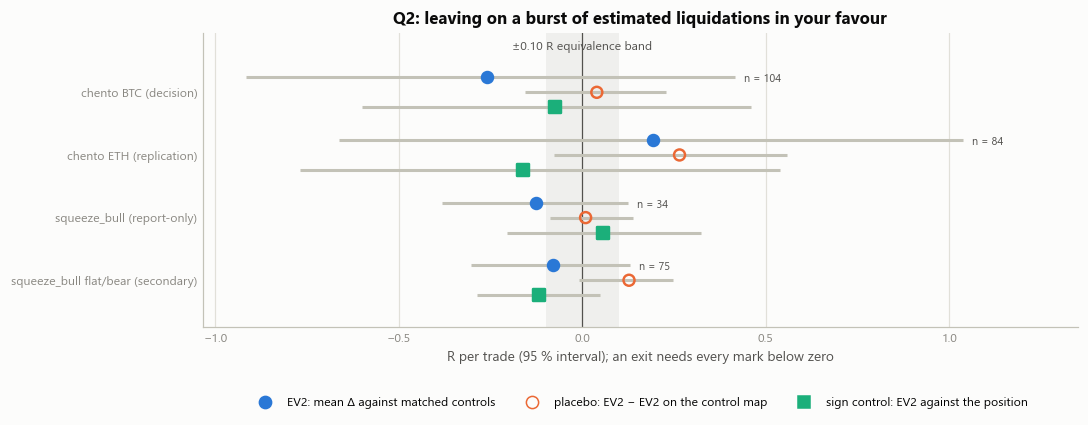

In [10]:
spec = [("EV2: mean Δ against matched controls", "EV2", SERIES[0], "o", True, +0.24),
        ("placebo: EV2 − EV2 on the control map", "PC", SERIES[1], "o", False, 0.0),
        ("sign control: EV2 against the position", "SC", SERIES[2], "s", True, -0.24)]
order = list(Q2.index)[::-1]
y = np.arange(len(order))
marks = []
for label, tag, colour, marker, filled, dy in spec:
    for yi, pop in zip(y, order):
        rows, p, axis_key = [x for x in LINES if x[0] == pop][0][1:4]
        v = (q2_delta(rows, p, "EV2", axis_key) if tag == "EV2" else
             q2_placebo(rows, p, "EV2", "EV2_ctrl", axis_key) if tag == "PC" else
             q2_delta(rows, p, "EV2_against", axis_key))
        marks.append((yi + dy, v, tag, colour, marker, filled))

fig, ax = plt.subplots(figsize=(10, 4.6))
for yi, v, tag, colour, marker, filled in marks:
    ax.hlines(yi, v["ci95"][0], v["ci95"][1], color=AXIS, linewidth=2, zorder=2)
    ax.scatter([v["mean"]], [yi], s=52, marker=marker, zorder=3, linewidths=1.6,
               color=colour if filled else "none", edgecolors=colour)
    if tag == "EV2":
        ax.annotate(f"n = {v['n']}", (v["ci95"][1], yi), xytext=(6, -3), textcoords="offset points",
                    fontsize=7, color=INK2)
lo = min(v["ci95"][0] for _, v, *_ in marks); hi = max(v["ci95"][1] for _, v, *_ in marks)
ax.set_xlim(lo - 0.06 * (hi - lo), hi + 0.16 * (hi - lo))
ax.axvspan(*L.BANDS["R"], color=NEUTRAL, alpha=0.18, linewidth=0, zorder=0)
ax.axvline(0, color=INK2, linewidth=0.8, zorder=1)
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8); ax.set_ylim(-0.75, len(order) - 0.05)
ax.annotate("±0.10 R equivalence band", xy=(0, len(order) - 0.12), ha="center", va="top",
            xytext=(0, -2), textcoords="offset points", fontsize=8, color=INK2)
style(ax, grid_axis="x"); ax.set_xlabel("R per trade (95 % interval); an exit needs every mark below zero")
ax.set_title("Q2: leaving on a burst of estimated liquidations in your favour")
ax.legend(handles=[Line2D([], [], linestyle="", marker=m, markersize=8, color=c if f else "none",
                          markerfacecolor=c if f else "none", markeredgecolor=c, label=lab)
                   for lab, _, c, m, f, _ in spec],
          loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3, fontsize=8)
plt.tight_layout(rect=(0, 0.10, 1, 1)); plt.show()

## 4. What the replicated result actually is

§7 of the pre-registration reserved one diagnostic for **after** the verdict was written: Δ by distance bin and by the
sign and size of `d_A − d_B`. It dissolves the touch result.

Everything in this section is recomputed from the same saved state tables and asserted against
`secondary_section7.json`.

In [11]:
def q1_frame(path):
    q = pd.read_csv(path).sort_values("ts", kind="mergesort")
    q["dA"], q["dB"] = q["d_A"].abs(), q["d_B"].abs()
    q["gap"] = q["dA"] - q["dB"]                       # negative: the actual map's cluster sits nearer price
    q["touch_delta"] = q["touch_A"] - q["touch_B"]
    return q


def gap_stat(rows, value):
    """`liqmap_explore._stat`: the study's paired bootstrap on a subset of states, claimed sign +1."""
    r = rows.sort_values("ts", kind="mergesort")
    axis = M.day_axis(r["day"])
    return L.paired_stats(r["day"], r[value].to_numpy(float), axis, M.block_indices(len(axis)), claimed_sign=+1)


Q = {"BTC": q1_frame(R / "q1_states.csv.gz"), "ETH": q1_frame(R / "q1_states_eth.csv.gz")}
for a, q in Q.items():
    s = SEC[a]
    assert len(q) == s["states"]
    assert abs(q["gap"].mean() - s["mean_gap"]) < 1e-12
    assert abs(q["dA"].median() - s["median_d_actual"]) < 1e-12
    assert abs(q["dB"].median() - s["median_d_control"]) < 1e-12
    assert abs(q["touch_delta"].mean() - s["all_states_touch_delta"]) < 1e-12
print("distance summaries recomputed from the state tables and matched secondary_section7.json exactly")
display(pd.DataFrame({a: {"states (both sides)": len(Q[a]),
                          "median |d| actual": f"{Q[a]['dA'].median():.2%}",
                          "median |d| control": f"{Q[a]['dB'].median():.2%}",
                          "mean gap |d_A| − |d_B|": f"{Q[a]['gap'].mean():+.2%}",
                          "actual cluster nearer": f"{(Q[a]['gap'] < 0).mean():.1%} of states",
                          "paired touch Δ, all states": f"{Q[a]['touch_delta'].mean() * 100:+.2f} pp"}
                      for a in ("BTC", "ETH")}))

distance summaries recomputed from the state tables and matched secondary_section7.json exactly


,BTC,ETH
states (both sides),12929,10371
median |d| actual,3.61%,3.62%
median |d| control,4.11%,4.20%
mean gap |d_A| − |d_B|,-0.44%,-0.44%
actual cluster nearer,64.8% of states,64.8% of states
"paired touch Δ, all states",+2.54 pp,+3.46 pp


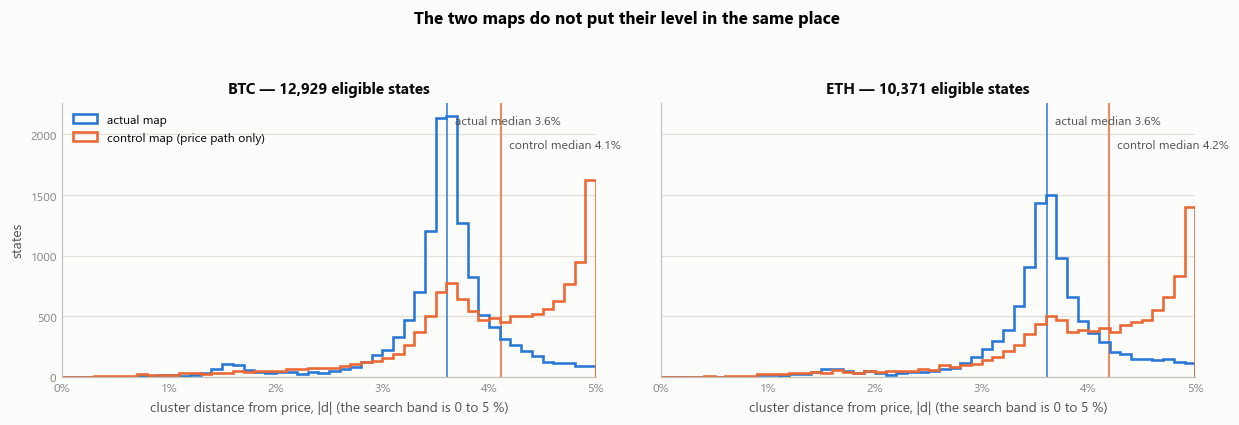

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9), sharey=True)
bins = np.arange(0, 0.0505, 0.001)
for ax, a in zip(axes, ("BTC", "ETH")):
    q = Q[a]
    ax.hist(q["dA"], bins=bins, histtype="step", color=SERIES[0], linewidth=1.7, label="actual map")
    ax.hist(q["dB"], bins=bins, histtype="step", color=SERIES[1], linewidth=1.7,
            label="control map (price path only)")
    top = ax.get_ylim()[1]
    for col, colour, name, dy in (("dA", SERIES[0], "actual", -8), ("dB", SERIES[1], "control", -24)):
        med = float(q[col].median())
        ax.axvline(med, color=colour, linewidth=1.0, zorder=1)
        ax.annotate(f"{name} median {med:.1%}", xy=(med, top), xytext=(5, dy), textcoords="offset points",
                    fontsize=8, color=INK2, va="top")
    style(ax); ax.set_xlim(0, 0.05)
    ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
    ax.set_title(f"{a} — {len(q):,} eligible states", fontsize=10)
    ax.set_xlabel("cluster distance from price, |d| (the search band is 0 to 5 %)")
axes[0].set_ylabel("states"); axes[0].legend(loc="upper left")
fig.suptitle("The two maps do not put their level in the same place", fontsize=11, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

The actual map's cluster sits **nearer price than the control map's in 64.8 % of states** on both assets, a mean gap of
−0.44 % of price. A nearer level is mechanically easier to touch inside 24 h. Split the states by the sign of that gap
and the whole touch difference is the split:

In [13]:
rows = []
for a in ("BTC", "ETH"):
    q = Q[a]
    for name, m, pretty in (("actual_nearer", q["gap"] < 0, "actual cluster nearer"),
                            ("control_nearer", q["gap"] > 0, "control cluster nearer"),
                            ("equal", q["gap"] == 0, "same distance (one bucket)")):
        sub, s = q[m], SEC[a]["by_sign_of_gap"][name]
        assert len(sub) == s["n"] and abs(sub["touch_delta"].mean() - s["touch_delta"]) < 1e-12, (a, name)
        rows.append({"asset": a, "states": pretty, "n": len(sub), "share": f"{len(sub) / len(q):.1%}",
                     "touch rate, actual": round(sub["touch_A"].mean(), 3),
                     "touch rate, control": round(sub["touch_B"].mean(), 3),
                     "Δ (pp)": round(sub["touch_delta"].mean() * 100, 2)})
display(pd.DataFrame(rows).set_index(["asset", "states"]))
print("where the distances are equal both maps name the same bucket and Δ is exactly zero — the pairing has no room "
      "left to produce a difference")

n  share  touch rate, actual  touch rate, control  Δ (pp)
asset states                                                                                  
BTC   actual cluster nearer       8381  64.8%               0.212                0.138    7.40
      control cluster nearer      3074  23.8%               0.217                0.312   -9.50
      same distance (one bucket)  1474  11.4%               0.195                0.195    0.00
ETH   actual cluster nearer       6719  64.8%               0.267                0.182    8.54
      control cluster nearer      2568  24.8%               0.238                0.321   -8.37
      same distance (one bucket)  1084  10.5%               0.267                0.267    0.00

where the distances are equal both maps name the same bucket and Δ is exactly zero — the pairing has no room left to produce a difference


So the test was never comparing two ways of choosing a level; it was comparing a nearer level with a farther one.
Matching on distance removes the entire effect. The tolerance is on `|d_A| − |d_B|`, and the interval is the same
paired bootstrap.

In [14]:
LADDER = [("all states", None, None), ("≤ 50 bp", 0.005, "within_50bp"), ("≤ 20 bp", 0.002, "within_20bp"),
          ("≤ 10 bp", 0.001, "within_10bp"), ("≤ 5 bp", 0.0005, "within_5bp")]
EXTRA = [("≤ 20 bp, distinct levels", "distinct_levels_within_20bp",
          lambda q: q[q["gap"].abs().between(1e-9, 0.002)], "touch_delta"),
         ("turn, ≤ 20 bp", "turn_within_20bp",
          lambda q: q[(q["touch_A"] == 1) & (q["touch_B"] == 1) & (q["gap"].abs() <= 0.002)], "turn_delta")]

ladder, rows = {}, []
for a in ("BTC", "ETH"):
    q = Q[a].copy(); q["turn_delta"] = q["turn_A"] - q["turn_B"]
    ladder[a] = {}
    for name, tol, key in LADDER:
        sub = q if tol is None else q[q["gap"].abs() <= tol]
        st = gap_stat(sub, "touch_delta")
        saved = SEC[a]["all_states"] if key is None else SEC[a]["distance_matched"][key]
        assert_same({**st, "n": len(sub)}, saved, where=f"{a} {key or 'all_states'}")
        ladder[a][name] = st
        rows.append({"asset": a, "tolerance": name, "n": st["n"], "Δ (pp)": round(st["mean"] * 100, 2),
                     "95 % low": round(st["ci95"][0] * 100, 2), "95 % high": round(st["ci95"][1] * 100, 2)})
    for name, key, sel, col in EXTRA:
        sub = sel(q); st = gap_stat(sub, col)
        assert_same({**st, "n": len(sub)}, SEC[a]["distance_matched"][key], where=f"{a} {key}")
        rows.append({"asset": a, "tolerance": name, "n": st["n"], "Δ (pp)": round(st["mean"] * 100, 2),
                     "95 % low": round(st["ci95"][0] * 100, 2), "95 % high": round(st["ci95"][1] * 100, 2)})
print(f"all {len(rows)} lines of the ladder — the 'all states' baseline included — recomputed and matched "
      "secondary_section7.json exactly (n, Δ, 95 % interval, one-sided p, both halves)")
display(pd.DataFrame(rows).set_index(["asset", "tolerance"]))

all 14 lines of the ladder — the 'all states' baseline included — recomputed and matched secondary_section7.json exactly (n, Δ, 95 % interval, one-sided p, both halves)


n  Δ (pp)  95 % low  95 % high
asset tolerance                                                   
BTC   all states                12929    2.54      1.78       3.33
      ≤ 50 bp                    5328    0.15     -0.23       0.59
      ≤ 20 bp                    3102    0.10     -0.09       0.30
      ≤ 10 bp                    2121    0.05      0.00       0.16
      ≤ 5 bp                     1474    0.00      0.00       0.00
      ≤ 20 bp, distinct levels   1628    0.18     -0.16       0.58
      turn, ≤ 20 bp               566    0.18     -1.54       2.00
ETH   all states                10371    3.46      2.53       4.42
      ≤ 50 bp                    3968    0.20     -0.18       0.56
      ≤ 20 bp                    2299    0.09     -0.08       0.27
      ≤ 10 bp                    1438   -0.07     -0.22       0.00
      ≤ 5 bp                     1084    0.00      0.00       0.00
      ≤ 20 bp, distinct levels   1215    0.16     -0.16       0.51
      turn, ≤ 20 bp               527   -0.95     -2.87       0.85

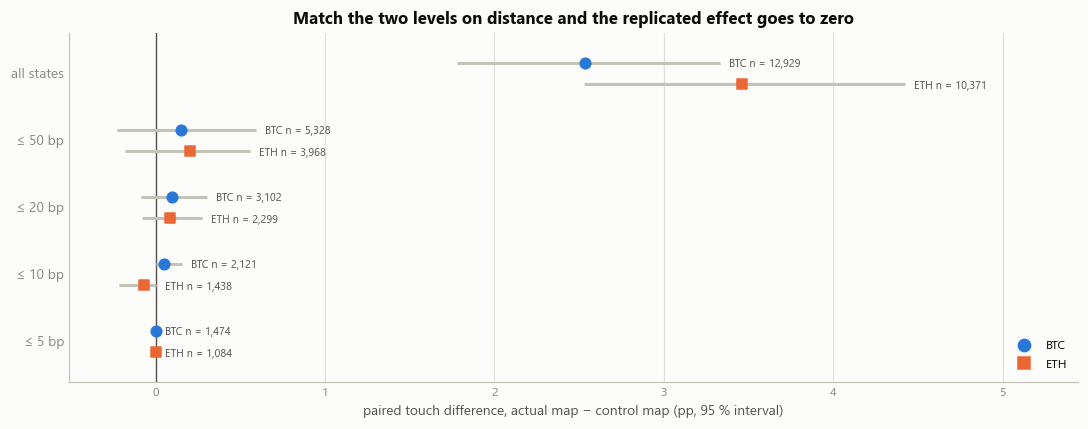

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.0))
names = [n for n, _, _ in LADDER]
y = np.arange(len(names))[::-1]
for asset, colour, marker, dy in (("BTC", SERIES[0], "o", +0.16), ("ETH", SERIES[1], "s", -0.16)):
    for yi, name in zip(y, names):
        st = ladder[asset][name]
        ax.hlines(yi + dy, st["ci95"][0] * 100, st["ci95"][1] * 100, color=AXIS, linewidth=2, zorder=2)
        ax.scatter([st["mean"] * 100], [yi + dy], s=48, marker=marker, color=colour, zorder=3)
        ax.annotate(f"{asset} n = {st['n']:,}", (max(st["ci95"][1] * 100, st["mean"] * 100), yi + dy),
                    xytext=(6, -3), textcoords="offset points", fontsize=7, color=INK2)
ax.axvline(0, color=INK2, linewidth=0.9, zorder=1)
lo = min(ladder[a][n]["ci95"][0] for a in ladder for n in names) * 100
hi = max(ladder[a][n]["ci95"][1] for a in ladder for n in names) * 100
ax.set_xlim(lo - 0.06 * (hi - lo), hi + 0.22 * (hi - lo))
ax.set_yticks(y); ax.set_yticklabels(names, fontsize=9); ax.set_ylim(-0.6, len(names) - 0.4)
style(ax, grid_axis="x")
ax.set_xlabel("paired touch difference, actual map − control map (pp, 95 % interval)")
ax.set_title("Match the two levels on distance and the replicated effect goes to zero")
ax.legend(handles=[Line2D([], [], linestyle="", marker="o", color=SERIES[0], markersize=8, label="BTC"),
                   Line2D([], [], linestyle="", marker="s", color=SERIES[1], markersize=8, label="ETH")],
          loc="lower right")
plt.tight_layout(); plt.show()

**So: the liquidation map's information does not tell you where price will go. It tells you to put your level nearer,
and nearer levels get touched more.** Two levels at the same distance are touched equally often whether the map knew
about open interest and taker flow or only about the price path.

This is the same trap the pre-registration was hardened against, one level deeper. The control map removed the *amount*
information but kept the price path, and the price path alone still produced clusters — just farther out. Pairing within
a state was not enough; the levels also had to be paired on distance. Next time a level study is pre-registered,
**matching on distance belongs in the primary test, not in §7.**

## 5. Verdict, and what it permits

- The pre-registered verdict is `REPLICATED: up_touch, down_touch`, and it must always be quoted with §4.
- §5 already ruled that a replicated Q1 without a replicated Q2 **permits nothing** for chento or squeeze_bull. §4
  removes even the descriptive claim: there is no evidence the map places levels better than the price path does.
- **No production change. No stage-B pre-registration is earned.**
- The estimated-liquidation **amount** series is worth keeping (range-controlled ρ ≈ 0.56 against measured
  liquidations, well above the naive proxy). Its side split is not.

**Do not re-propose:** "take profit at the nearest dense liquidation cluster" on chento or squeeze_bull (undecidable at
this frequency, 9 included trades, and indistinguishable from a price-path level at the same distance); "exit on a burst
of estimated liquidations in your favour" (null on BTC and ETH against a placebo built by the same rules); this model's
taker-share side split (beaten by `(open − low)` versus `(high − open)`).

A future liquidation-map idea needs a different input, not a different dial: real liquidation prints at second
resolution (the collector now records them from Bybit and OKX, where the full stream is public), or venue-published
liquidation levels. Both are outside the public 5-minute archive this study was built on.

In [16]:
print(json.dumps(VER, indent=1))

{
 "created_utc": "2026-09-18T10:03:49+00:00",
 "f0_created_utc": "2026-09-18T10:02:21+00:00",
 "classifications": {
  "up_touch": "INFORMATIVE",
  "up_turn": "UNDETERMINED",
  "down_touch": "INFORMATIVE",
  "down_turn": "UNDETERMINED",
  "chento:EV1": "DESCRIPTIVE",
  "chento:EV1_ctrl": "DESCRIPTIVE",
  "chento:EV2": "UNDETERMINED",
  "chento:EV2_ctrl": "DESCRIPTIVE",
  "chento:EV2_against": "DESCRIPTIVE",
  "squeeze_bull:EV1": "DESCRIPTIVE",
  "squeeze_bull:EV1_ctrl": "DESCRIPTIVE",
  "squeeze_bull:EV2": "DESCRIPTIVE",
  "squeeze_bull:EV2_ctrl": "DESCRIPTIVE",
  "squeeze_bull:EV2_against": "DESCRIPTIVE",
  "squeeze_bull_secondary:EV1": "DESCRIPTIVE",
  "squeeze_bull_secondary:EV1_ctrl": "DESCRIPTIVE",
  "squeeze_bull_secondary:EV2": "DESCRIPTIVE",
  "squeeze_bull_secondary:EV2_ctrl": "DESCRIPTIVE",
  "squeeze_bull_secondary:EV2_against": "DESCRIPTIVE"
 },
 "informative_btc": [
  "up_touch",
  "down_touch"
 ],
 "family": [
  "up_touch",
  "up_turn",
  "down_touch",
  "down_turn",
  "c